# cu_inj initial distributions

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from distgen import Generator

from pmd_beamphysics import ParticleGroup
from pmd_beamphysics.interfaces.impact import parse_impact_particles, impact_particles_to_particle_data

import numpy as np

import os

# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['figure.figsize'] = (12,4)

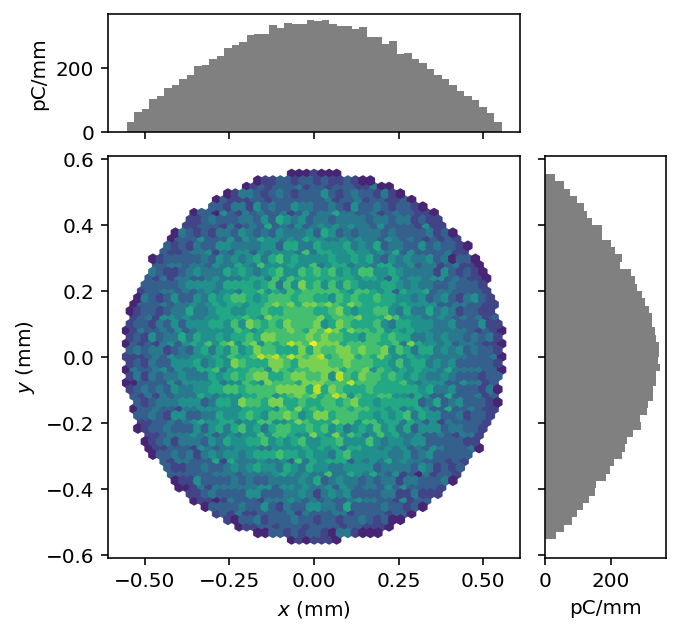

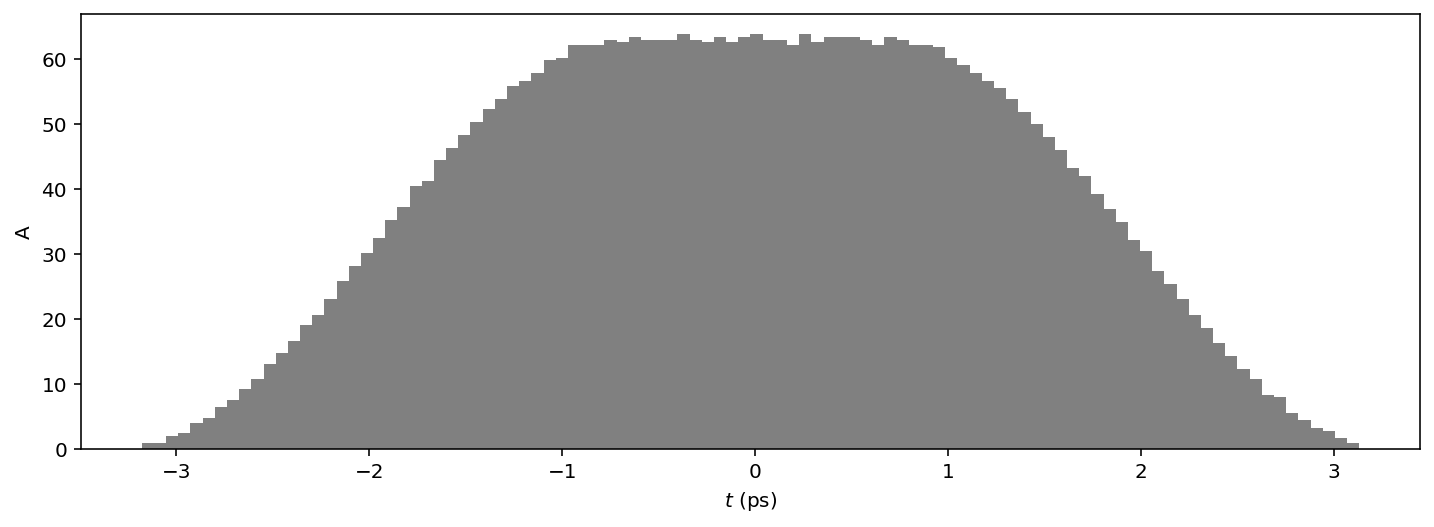

In [3]:
G0 = Generator('$LCLS_LATTICE/distgen/models/cu_inj/v0/distgen.yaml')
G0['n_particle'] = 10000
G0.run()
P0 = G0.particles
P0.plot('x', 'y', figsize=(5,5))
P0.plot('t')

# Compare with actual generated particles

In [4]:
# Partcl.data
name1 = 'partcl.data'
pfile = os.path.join(os.environ['LCLS_LATTICE'], 'impact/models/cu_inj/v0/partcl.data')
assert os.path.exists(pfile)

tout = parse_impact_particles(pfile, skiprows=1)
data = impact_particles_to_particle_data(tout, mc2=0.511e6, species='electron', macrocharge=0, cathode_kinetic_energy_ref=1.0, verbose=True )
P1 = ParticleGroup(data=data)

# Center
P1.t -= P1['mean_t']

Converting z to t according to cathode_kinetic_energy_ref = 1.0 eV


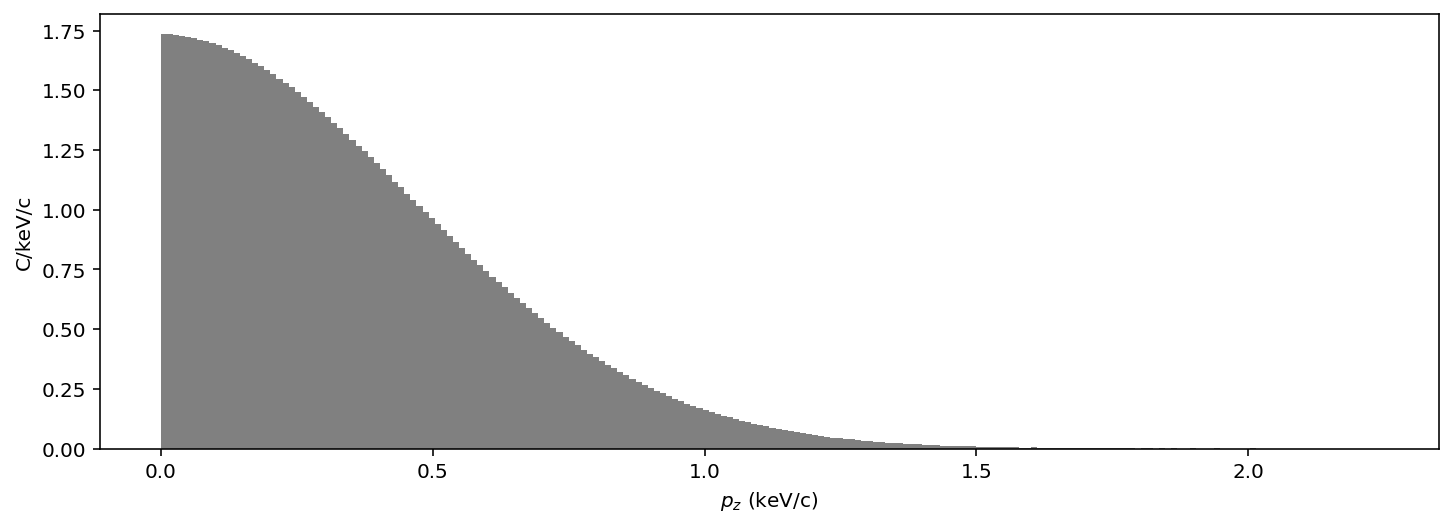

In [5]:
P1.plot('pz', bins=200)

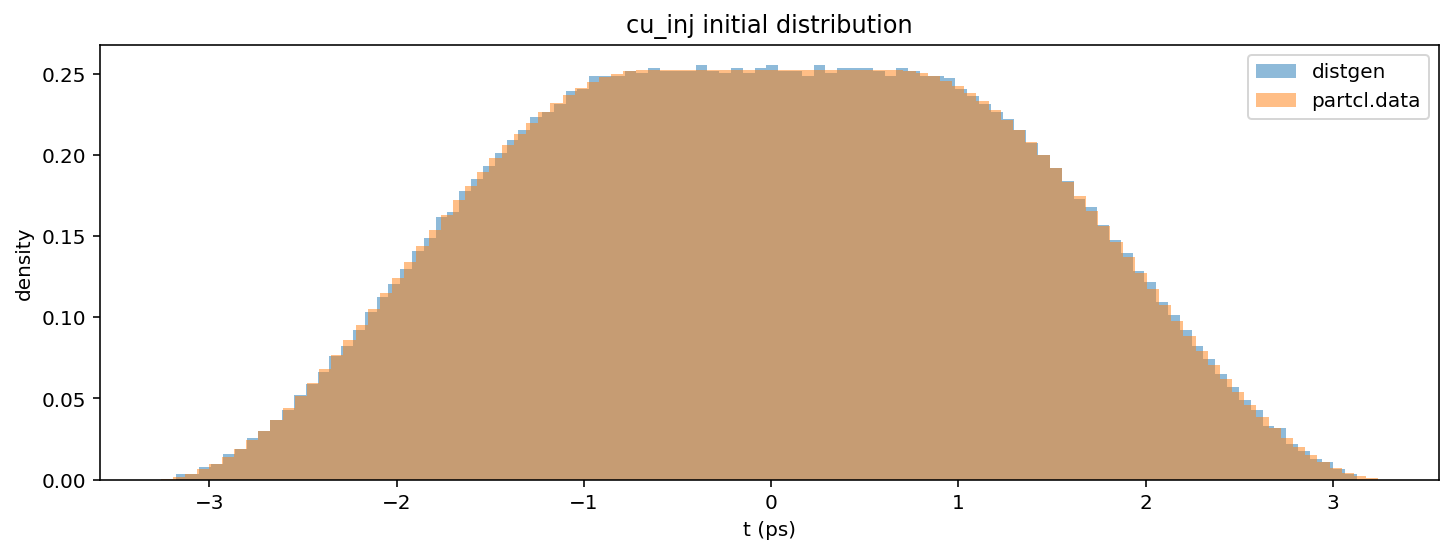

In [6]:
k = 't'
plt.hist(P0[k]*1e12, label='distgen', alpha = 0.5, density=True, bins=100)
plt.hist(P1[k]*1e12, label=name1, alpha=0.5, density=True, bins=100)

plt.title('cu_inj initial distribution')
plt.xlabel('t (ps)')
plt.ylabel('density')
plt.legend()
#plt.savefig('test.png')

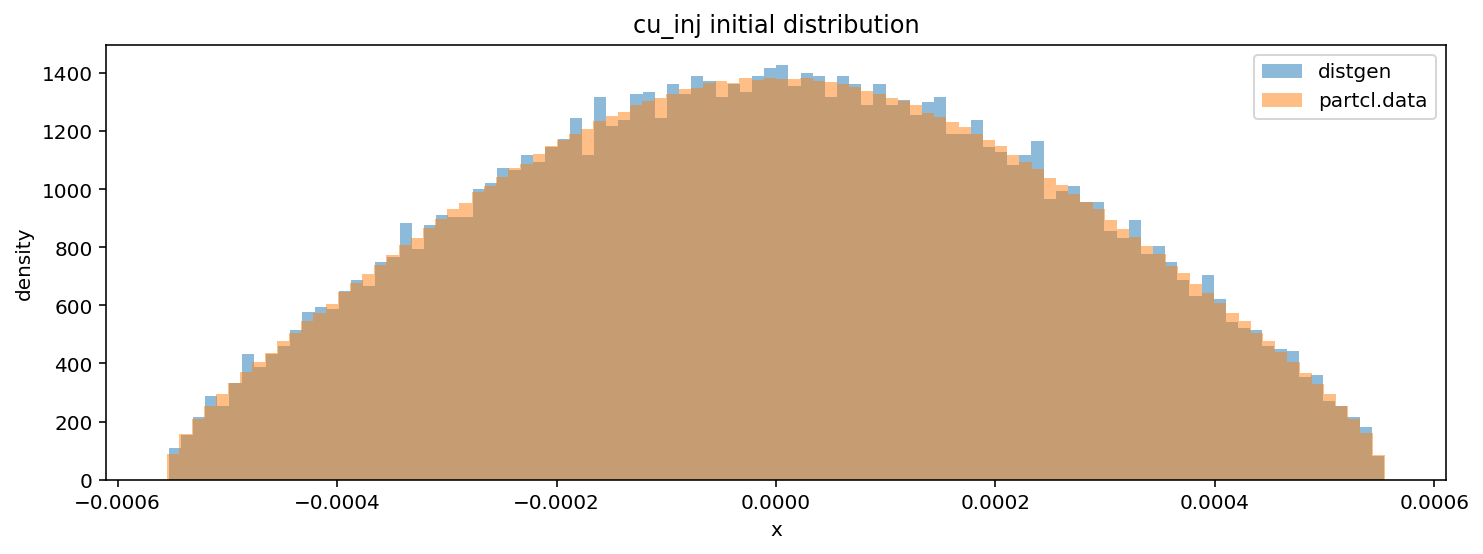

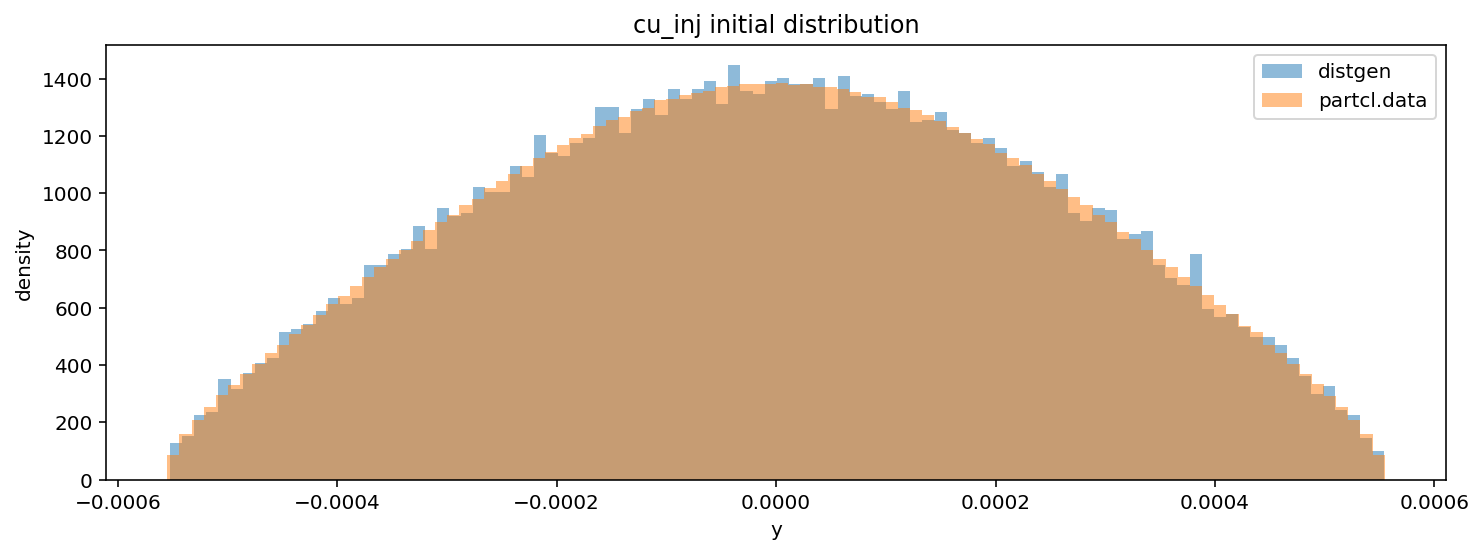

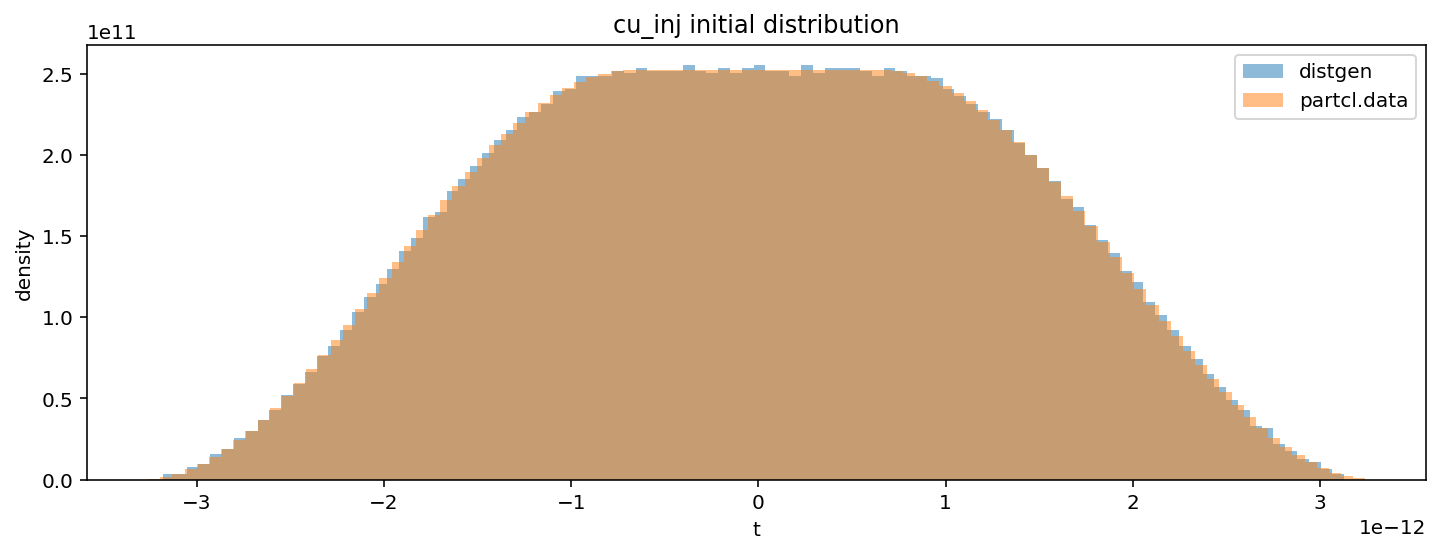

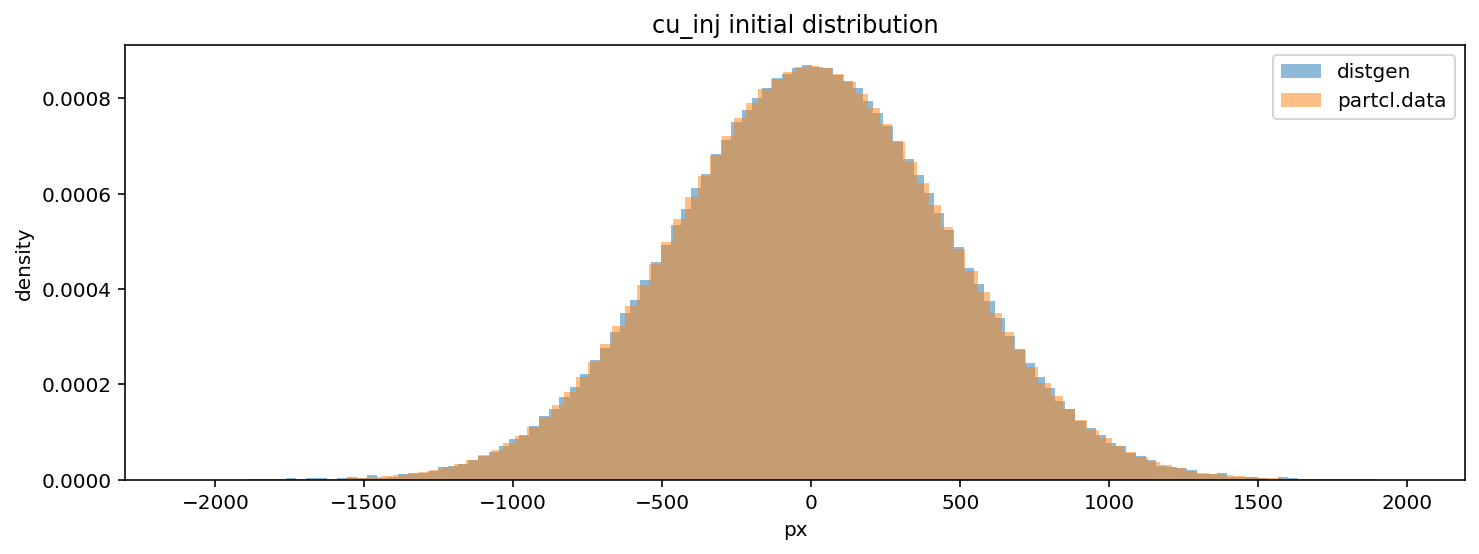

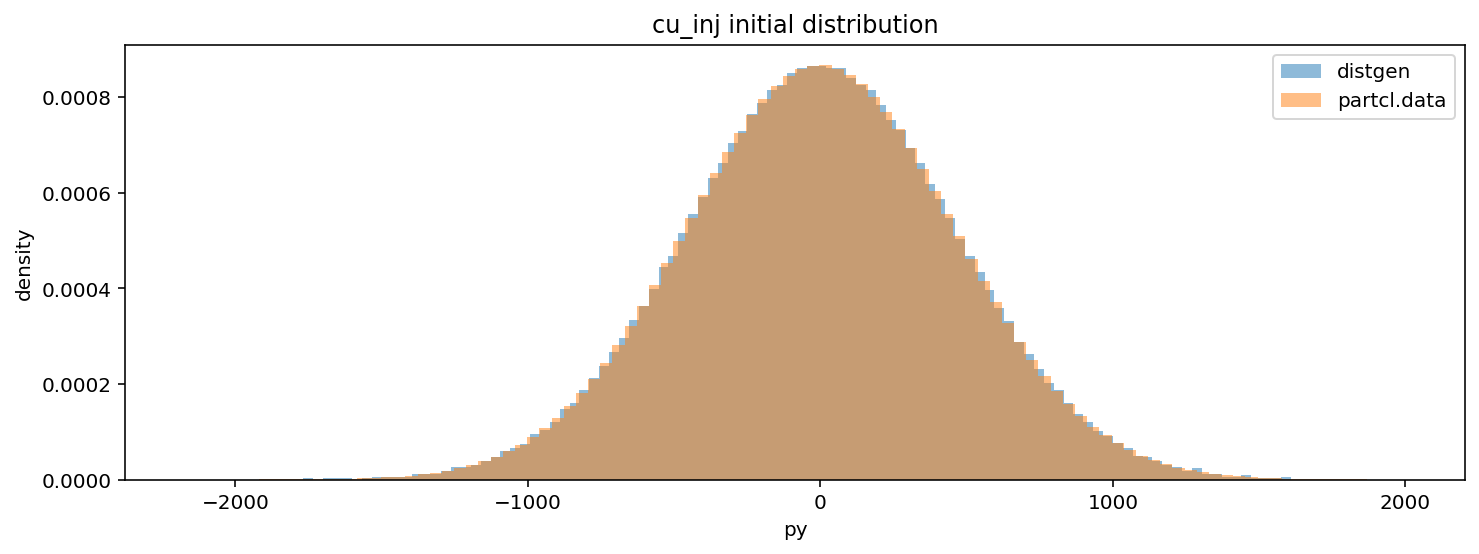

In [7]:
for k in ['x', 'y', 't', 'px', 'py']:
    plt.hist(P0[k], label='distgen', alpha = 0.5, density=True, bins=100)
    plt.hist(P1[k], label=name1, alpha=0.5, density=True, bins=100)
    
    plt.title('cu_inj initial distribution')
    plt.xlabel(k)
    plt.ylabel('density')
    plt.legend()
    plt.show()

# Flat 2 Gaussian

Two overlapping Gaussians with the same standard deviation $\sigma$ give a reasonably flat center when the offsets are $\pm \sigma$

Because the FWHM for a single Gaussian is $W_{1G}=2\sqrt{2\log2}\sigma$, this disribution has a FWHM of $W_{2G}=2(1+\sqrt{2\log2})\sigma$, or about $4.355\sigma$

The shortest LCLS copper injector single pulse is about 1 ps FWHM, so therefore the shortest pulse here is $W_{2G}=1.85$ ps


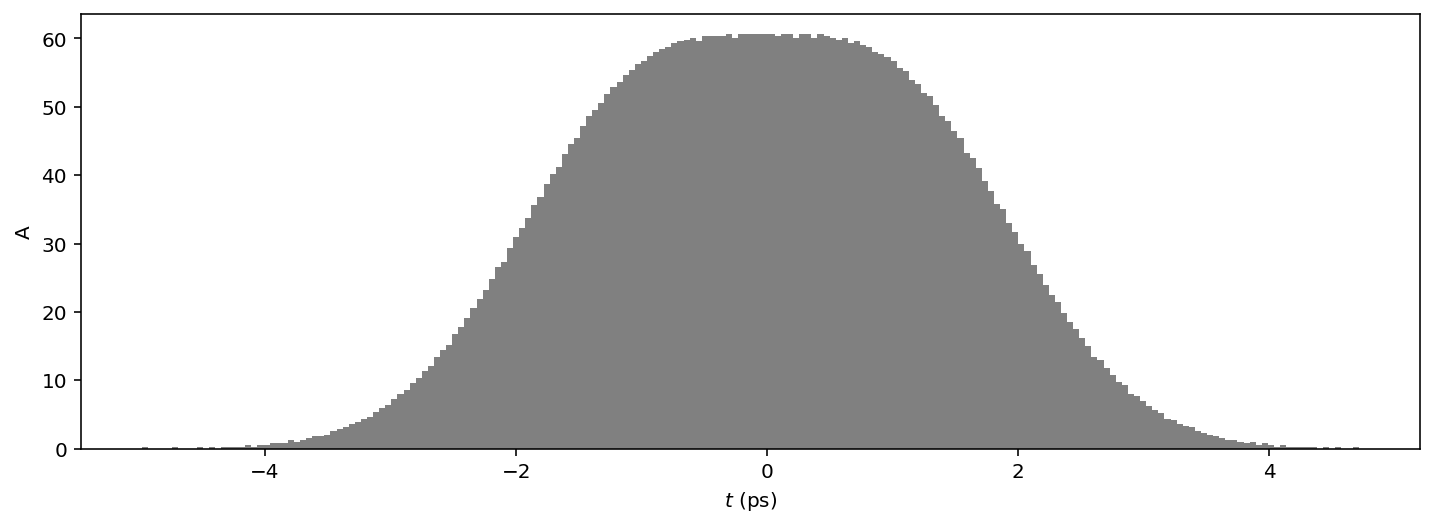

In [8]:
G2 = Generator('$LCLS_LATTICE/distgen/models/cu_inj/2gauss/distgen.yaml')

sigma =1
offset = sigma
G2['n_particle'] = 20000
G2['t_dist:dists:d1:avg_t:value'] = -offset 
G2['t_dist:dists:d2:avg_t:value'] = offset 
G2['t_dist:dists:d1:sigma_t:value'] = sigma
G2['t_dist:dists:d2:sigma_t:value'] = sigma
G2.run()
P2 = G2.particles
P2.plot('t')

In [9]:
# Statistical sigma
P2['sigma_t']

1.4142083032026764e-12

# Tukey Approximation

The tukey distribution gives a reasonably good approximation to the Flat 2 Gaussian above when the tukey ratio is about 0.85 and the tukey length $l=7.2\sigma$.

This is the same as $l\approx3 W_{1G}$, and $l\approx  1.65 W_{2G}$.

Therefore the shortest tukey length in LCLS is about 3 ps.



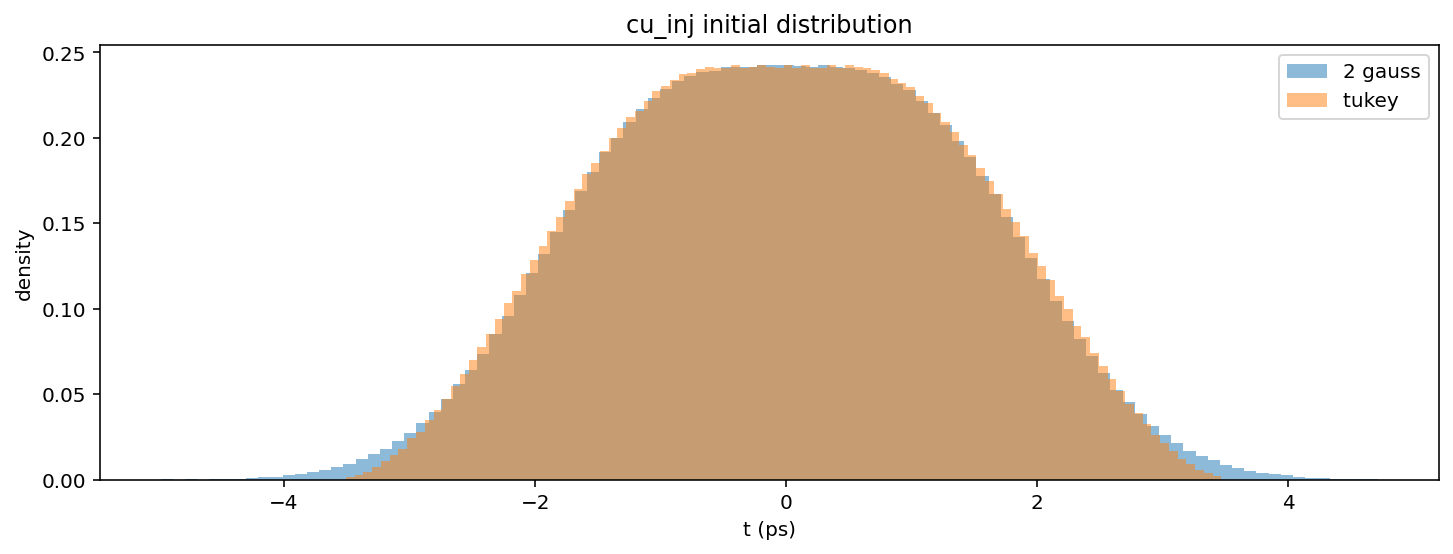

In [10]:
G3 = Generator('v0/distgen.yaml')
G3['n_particle'] = 20000
G3['t_dist:length:value'] = 7.2
G3['t_dist:ratio:value'] = 0.85
G3.run()
P3 = G3.particles

k = 't'
plt.hist(P2[k]*1e12, label='2 gauss', alpha = 0.5, density=True, bins=100)
plt.hist(P3[k]*1e12, label='tukey ', alpha=0.5, density=True, bins=100)

plt.title('cu_inj initial distribution')
plt.xlabel('t (ps)')
plt.ylabel('density')
plt.legend()
#plt.savefig('test.png')

In [11]:
# Statistical sigma is a little shorter
P3['sigma_t']

1.3681147355740225e-12

# VCC image

In [12]:
G4 = Generator('$LCLS_LATTICE/distgen/models/cu_inj/vcc_image/distgen.yaml')
G4['n_particle'] = 100000
G4.run()
P4 = G4.particles

G4

<disgten.Generator with input: 
n_particle: 100000
random_type: hammersley
start:
  MTE:
    units: meV
    value: 414
  type: cathode
t_dist:
  length:
    units: ps
    value: 7.5
  ratio:
    units: ''
    value: 0.8
  type: tukey
total_charge:
  units: pC
  value: 250
transforms:
  order:
  - tx
  - ty
  tx:
    avg_x:
      units: mm
      value: 0
    type: set_avg x
  ty:
    avg_y:
      units: mm
      value: 0
    type: set_avg y
xy_dist:
  file: /Users/chrisonian/Code/GitHub/lcls-lattice/distgen/models/cu_inj/vcc_image/laser_image.txt
  type: file2d

>

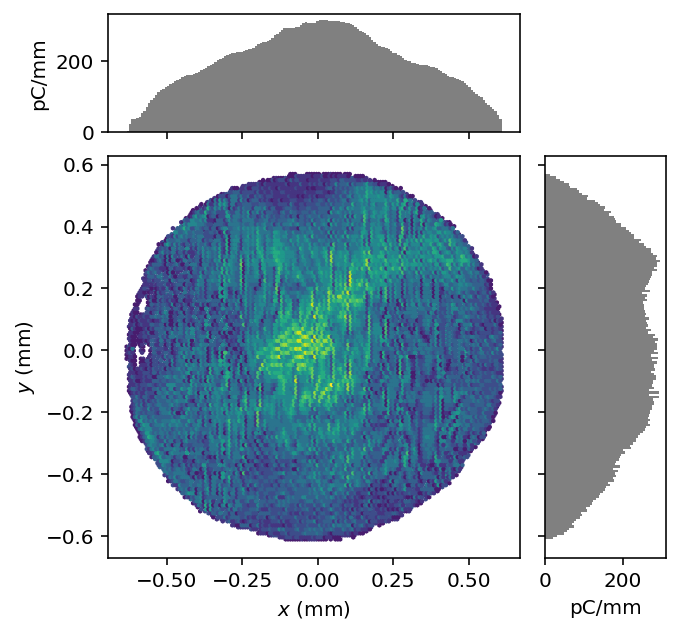

In [13]:
P4.plot('x', 'y', figsize=(5,5))

# VCC Image with QE map

Make a random mask to simulate a QE map

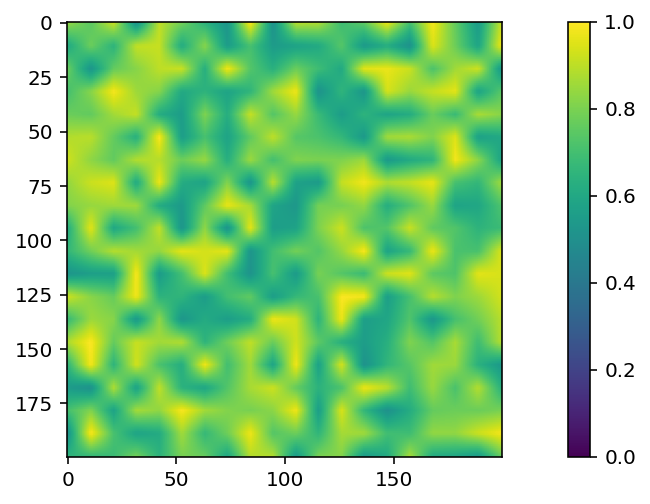

In [14]:
from scipy import ndimage

laser = {'type': 'rg',
            'truncation_fraction': {'units': 'dimensionless', 'value': 0.5},
            'truncation_radius': {'units': 'mm', 'value': 2}}


shape = (20,20)
#mask = np.zeros(shape)
#mask[:shape[0]//2, :shape[1]//2] = 1

np.random.seed(99)

mask = (np.random.rand(*shape) +1)/2
mask = ndimage.zoom(mask, 10, order=1)
#mask[:mask.shape[0]//2, :mask.shape[1]//2] *=4

#mask[:] = 1
ys = np.linspace(-2, 2, mask.shape[0])
xs = np.linspace(-2, 2, mask.shape[1])

QE =  {
    'type': 'image2d',
    'x':{'value':xs, 'units':'mm'},
    'y':{'value':ys, 'units':'mm'},
    'P':mask
}
plt.imshow(mask, vmin=0, vmax=1)
plt.colorbar()

CPU times: user 2.93 s, sys: 64.9 ms, total: 3 s
Wall time: 2.38 s


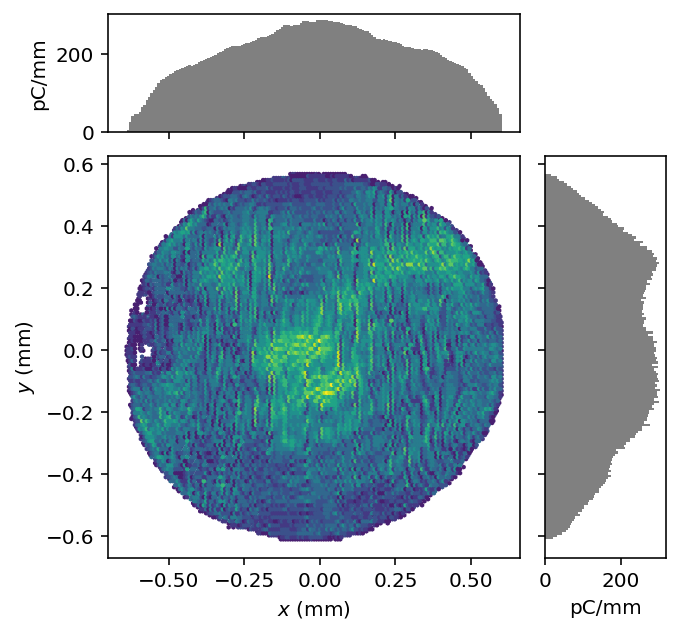

In [15]:
%%time
G5 = Generator('$LCLS_LATTICE/distgen/models/cu_inj/vcc_image/distgen.yaml')
laser = G5.input['xy_dist'].copy()

G5['xy_dist'] =  {'type':'product', 'dists':{'Laser':laser, 'QE':QE}}

G5['n_particle'] = 100000
G5.run()

P5 = G5.particles
P5.plot('x', 'y', figsize=(5,5))